tf-idf com lematização e stemming em tweets #edtwt

In [1]:
%pip install scikit-learn plotly seaborn matplotlib pandas numpy nltk spacy nbformat>=4.2.0 --quiet

zsh:1: 4.2.0 not found
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import ast
import warnings
import numpy as np
import pandas as pd

import spacy
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

seed = 42

In [3]:
!python -m spacy download pt_core_news_lg --quiet


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')


carregamento dos dados

In [4]:
DATA_DIR = os.getcwd()
csv_path = os.path.join(DATA_DIR, '..', 'entregas', 'p2', 'entrega_2.csv')
json_path = os.path.join(DATA_DIR, '..', 'entregas', 'p2', 'entrega_2_tfidf_features.json')

if not os.path.exists(csv_path):
    raise FileNotFoundError(f'Arquivo nao encontrado: {csv_path}')

df = pd.read_csv(csv_path)
print(f'Dataset: {df.shape[0]} tweets, {df.shape[1]} colunas')
print('colunas relevantes: text, normalizacao_re, features_tfidf_sklearn')

Dataset: 2353 tweets, 34 colunas
Colunas relevantes: text, normalizacao_re, features_tfidf_sklearn


pré-processamento: lematização + stemming

In [5]:
nlp = spacy.load('pt_core_news_lg', disable=['ner', 'parser'])
stemmer = SnowballStemmer('portuguese')

def lematizar_e_stem(texto):
    if not texto or not isinstance(texto, str) or not texto.strip():
        return ''
    doc = nlp(texto[:500])
    tokens = []
    for token in doc:
        if token.is_punct or token.is_space:
            continue
        lemma = token.lemma_.strip()
        if lemma:
            stem = stemmer.stem(lemma.lower())
            if stem:
                tokens.append(stem)
    return ' '.join(tokens)

exemplo = df['normalizacao_re'].iloc[0]
print(f'Original:  {exemplo[:120]}')
print(f'Processado: {lematizar_e_stem(exemplo)[:120]}')

Original:  refeiçõ hj wieiad gent esquec tir fot almoc arroz cenour steak frang 1 244 kcals 43 2 g prot gast klcals caminh muscul m
Processado: refeiçõ hj wieiad gent esquec tir fot almoc arroz cenour steak frang 1 244 kcals 43 2 g prot gast klcals caminh muscul m


In [6]:
from tqdm.auto import tqdm

textos_normalizados = df['normalizacao_re'].fillna('').values

print('aplicando lematizacao + stemming em todos os tweets...')
textos_processados = [lematizar_e_stem(t) for t in tqdm(textos_normalizados, desc='Processando')]

vazios = sum(1 for t in textos_processados if not t)
print(f'Tweets processados: {len(textos_processados)}')
print(f'Tweets sem tokens apos processamento: {vazios}')

Aplicando lematizacao + stemming em todos os tweets...


Processando:   0%|          | 0/2353 [00:00<?, ?it/s]

Tweets processados: 2353
Tweets sem tokens apos processamento: 0


tf-idf sobre texto lematizado + stemmizado

In [7]:
vetorizador_lemmastem = TfidfVectorizer(
    lowercase=False,
    max_df=0.85,
    min_df=2,
    max_features=1000,
    token_pattern=r"(?u)\b\w\w+\b",
)

matriz_lemmastem = vetorizador_lemmastem.fit_transform(
    [t if t else ' ' for t in textos_processados]
)
vocabulario_lemmastem = vetorizador_lemmastem.get_feature_names_out()

print(f'Vocabulario: {len(vocabulario_lemmastem)} termos')
print(f'Matriz TF-IDF: {matriz_lemmastem.shape}')
print(f'Termos mais frequentes (TF-IDF): {vocabulario_lemmastem[np.argsort(matriz_lemmastem.sum(axis=0).A1)[-15:][::-1]]}')

Vocabulario: 1000 termos
Matriz TF-IDF: (2353, 1000)
Termos mais frequentes (TF-IDF): ['com' 'pra' 'ir' 'dia' 'thread' 'kg' 'almoc' 'recovery' 'hoj' 'pro' 'fic'
 'to' 'entrar' 'calor' 'ed']


In [8]:
vetores_lemmastem = matriz_lemmastem.toarray().astype(np.float32)
documentos = df['text'].values

print(f'Vetores TF-IDF (lemmatizacao+stemming): {vetores_lemmastem.shape}')
print(f'Dimensao: {vetores_lemmastem.shape[1]}')
print(f'Densidade media: {(vetores_lemmastem > 0).mean():.2%}')

Vetores TF-IDF (lemmatizacao+stemming): (2353, 1000)
Dimensao: 1000
Densidade media: 0.67%


diagnóstico da similaridade de cosseno

In [9]:
sim_raw = cosine_similarity(vetores_lemmastem)
upper_raw = sim_raw[np.triu_indices_from(sim_raw, k=1)]

print('=== Similaridade de Cosseno ORIGINAL (sem centralizacao) ===')
print(f'  Media: {upper_raw.mean():.6f}')
print(f'  Desvio padrao: {upper_raw.std():.6f}')
print(f'  Minimo: {upper_raw.min():.4f}  |  Maximo: {upper_raw.max():.4f}')
print(f'  Mediana: {np.median(upper_raw):.6f}')

=== Similaridade de Cosseno ORIGINAL (sem centralizacao) ===
  Media: 0.014870
  Desvio padrao: 0.056094
  Minimo: 0.0000  |  Maximo: 1.0000
  Mediana: 0.000000


In [10]:
vetor_medio_global = vetores_lemmastem.mean(axis=0)
vetores_centralizados = vetores_lemmastem - vetor_medio_global

sim_cent = cosine_similarity(vetores_centralizados)
upper_cent = sim_cent[np.triu_indices_from(sim_cent, k=1)]

print('=== Similaridade de Cosseno CENTRALIZADA (mean-centering) ===')
print(f'  Media: {upper_cent.mean():.6f}')
print(f'  Desvio padrao: {upper_cent.std():.6f}')
print(f'  Minimo: {upper_cent.min():.4f}  |  Maximo: {upper_cent.max():.4f}')
print(f'  Mediana: {np.median(upper_cent):.6f}')

=== Similaridade de Cosseno CENTRALIZADA (mean-centering) ===
  Media: -0.000196
  Desvio padrao: 0.060085
  Minimo: -0.2786  |  Maximo: 1.0000
  Mediana: -0.011843


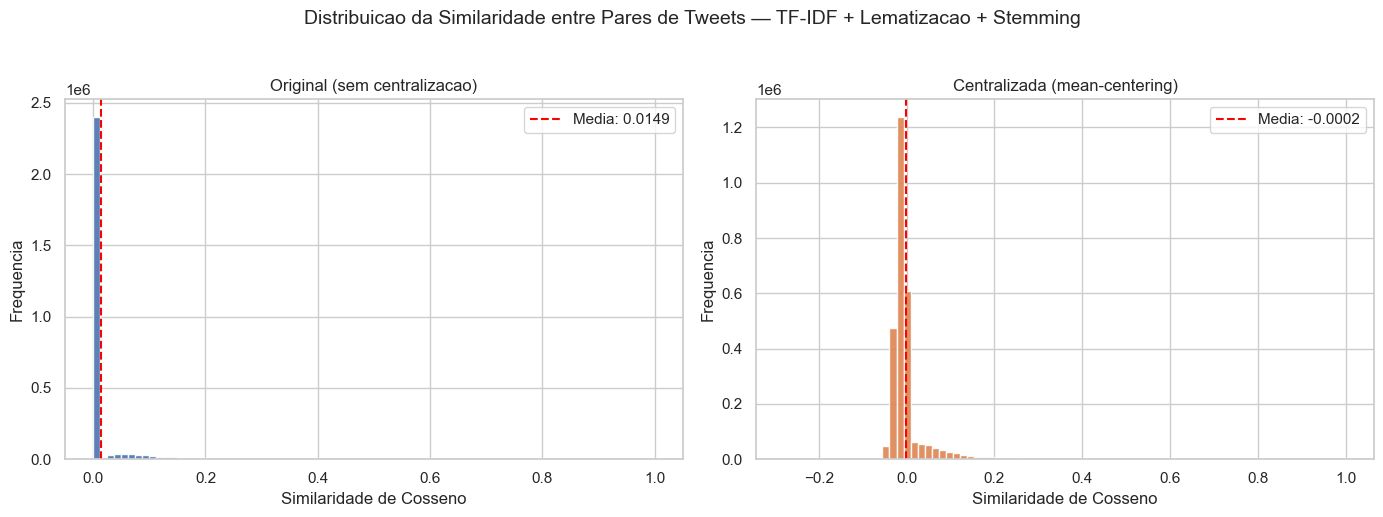

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(upper_raw, bins=80, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0].axvline(upper_raw.mean(), color='red', linestyle='--', label=f'Media: {upper_raw.mean():.4f}')
axes[0].set_title('Original (sem centralizacao)', fontsize=12)
axes[0].set_xlabel('Similaridade de Cosseno')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

axes[1].hist(upper_cent, bins=80, color='#DD8452', edgecolor='white', alpha=0.9)
axes[1].axvline(upper_cent.mean(), color='red', linestyle='--', label=f'Media: {upper_cent.mean():.4f}')
axes[1].set_title('Centralizada (mean-centering)', fontsize=12)
axes[1].set_xlabel('Similaridade de Cosseno')
axes[1].set_ylabel('Frequencia')
axes[1].legend()

plt.suptitle('Distribuicao da Similaridade entre Pares de Tweets — TF-IDF + Lematizacao + Stemming', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

heatmap de similaridade centralizada (amostra)

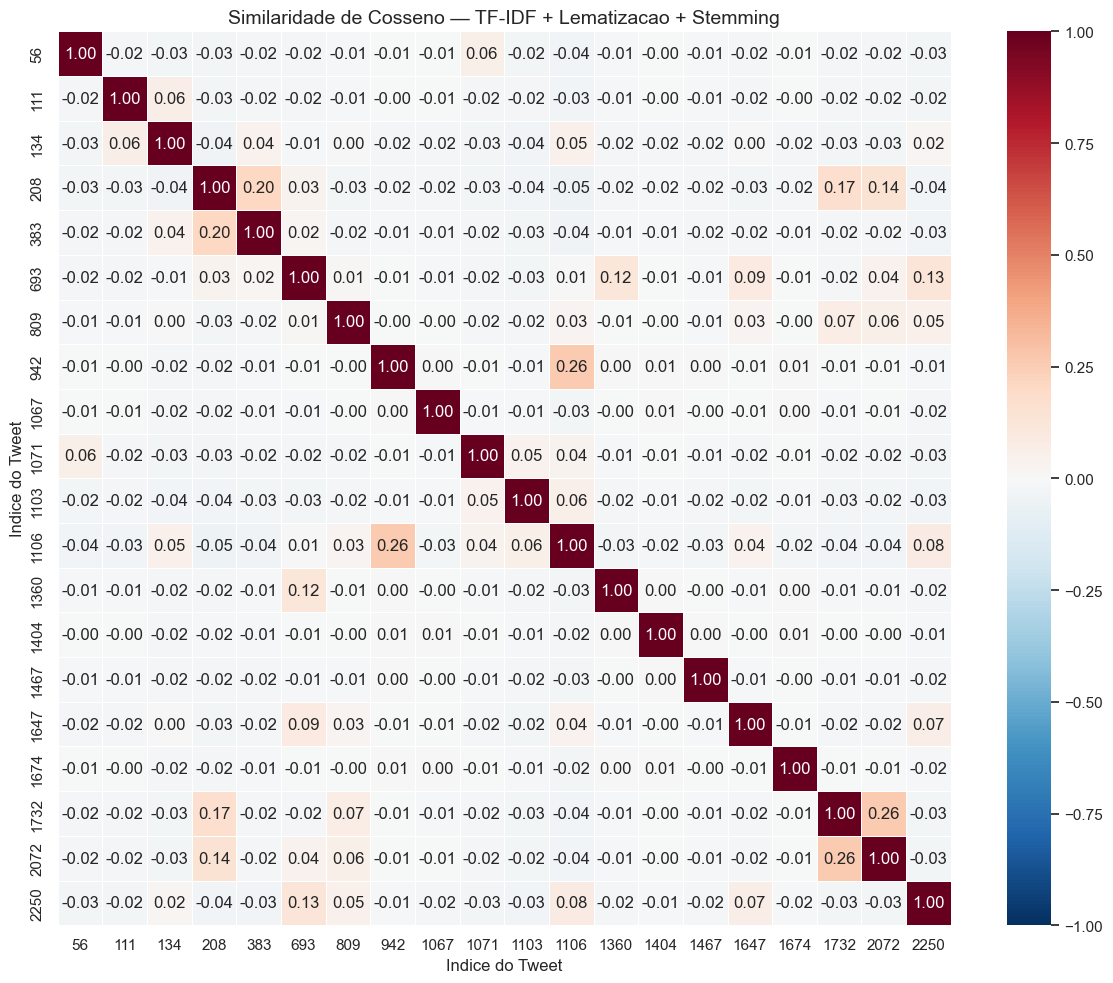

In [12]:
np.random.seed(seed)
n_amostra = min(20, len(documentos))
indices_amostra = np.sort(np.random.choice(len(documentos), size=n_amostra, replace=False))

matriz_amostra = sim_cent[np.ix_(indices_amostra, indices_amostra)]
labels = [str(i) for i in indices_amostra]

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_amostra,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=.5,
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1, vmax=1
)
plt.title('Similaridade de Cosseno — TF-IDF + Lematizacao + Stemming', fontsize=14)
plt.xlabel('Indice do Tweet', fontsize=12)
plt.ylabel('Indice do Tweet', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
print('tweets da amostra:\n')
for i in indices_amostra:
    texto = documentos[i].replace('\n', ' ')[:90]
    print(f'  [{i}] {texto}{"..." if len(documentos[i]) > 90 else ""}')

Tweets da amostra:

  [56] Uma mulher de 40 anos agindo como adolescente, antes do atestado, no final do plantão a fa...
  [111] 24h de nf, se eu n conseguir isso sou uma inutil #edtwt
  [134] Duas armaguradas, gordas e são viciadas em álcool e eu fiz mentira vira verdade eu não fum...
  [208] preciso perder 5kg logo #bc #shedtwt #edtwt https://t.co/p22rFW53c0
  [383] pessoas que são/já foram acima de 70kg me respondam:  o que fizeram vocês perder peso de f...
  [693] quando vc pede skinny jeans emprestado pra sua namorada de 1,60 50kg e ainda tem que usar ...
  [809] Receitas saudáveis,low carb e sem açucares pra o natal 🌲✨️ Uma #thread para o #edtwt 🧵 htt...
  [942] Omad com copo da felicidade amanhã.. Apoiam?  #edtwt
  [1067] Nós do pony club assumimos hj que somos do #edtwt
  [1071] fiquei com preguiça de fazer comida ontem e trouxe pipoca para almoçar #edtwt
  [1103] Emagreci dms slc acho q comi um verme #edtwt https://t.co/QOksUHG0Ld
  [1106] Não vou comer amanhã no senai pra com

agrupamento (clustering) com kmeans

In [14]:
num_clusters = 3

kmeans = KMeans(n_clusters=num_clusters, random_state=seed, n_init=10)
kmeans.fit(vetores_centralizados)

df_cluster = pd.DataFrame({'Tweet': documentos, 'Cluster': kmeans.labels_})

print(f'Agrupamento com {num_clusters} clusters:\n')
for c in range(num_clusters):
    cluster = df_cluster[df_cluster['Cluster'] == c]
    print(f'  Cluster {c} ({len(cluster)} tweets):')
    for s in cluster['Tweet'].head(3):
        print(f'    - {s.replace(chr(10), " ")[:100]}')
    print()

print('top termos discriminativos por cluster:')
for c in range(num_clusters):
    mascara = kmeans.labels_ == c
    centroide = vetores_lemmastem[mascara].mean(axis=0)
    centroide_outros = vetores_lemmastem[~mascara].mean(axis=0)
    diff = centroide - centroide_outros
    top_indices = np.argsort(diff)[-10:][::-1]
    print(f'  Cluster {c}: {", ".join(vocabulario_lemmastem[i] for i in top_indices)}')
    print()

Agrupamento com 3 clusters:

  Cluster 0 (152 tweets):
    - ︶ ⏝ ︶ ୨୧ ︶ ⏝ ︶ |                    ALMOÇO.  |            Peso  atual  ::  52kg  . |                
    - tô no peso ideal amores? 1,64 com 54 kg #edtwt
    - ︶ ⏝ ︶ ୨୧ ︶ ⏝ ︶ |                    EXERCÍCIOS.  |            Peso  atual  ::  52kg  . |            

  Cluster 1 (2115 tweets):
    - Refeições de hj! #wieiad ₍ᐢ. .ᐢ₎ ．☆．。．:*･ﾟ  Gente eu esqueci de tirar foto do almoço, mas foi arroz 
    - em quanto tempo vocês tiveram resultados notáveis na academia ?  #edtwt #gymtwt #gymgirl
    - A geladeira do edtwt que mora sozinha  #edtwt #nofood  #diet #zerosugar https://t.co/SRvInSbGuj

  Cluster 2 (86 tweets):
    - decidi não almoçar hoje para beber clericot está mt calor #edtwt
    - decidi não almoçar hoje para beber clericot está mt calor #edtwt
    - decidi não almoçar hoje para beber clericot está mt calor #edtwt

Top termos discriminativos por cluster:
  Cluster 0: kg, perd, shedtwt, bc, prec, pes, seman, 50, 45, fix


visualização 2d com pca e t-sne

In [15]:
pca_2d = PCA(n_components=2, random_state=seed)
vetores_pca = pca_2d.fit_transform(vetores_centralizados)

var_exp = pca_2d.explained_variance_ratio_
print(f'Variancia explicada: PC1={var_exp[0]:.2%}, PC2={var_exp[1]:.2%}')
print(f'Variancia total explicada (2 PCs): {var_exp.sum():.2%}')

plot_df_pca = pd.DataFrame({
    'PCA 1': vetores_pca[:, 0],
    'PCA 2': vetores_pca[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_pca = px.scatter(
    plot_df_pca, x='PCA 1', y='PCA 2', color='Cluster',
    title=f'PCA 2D: Clusters — TF-IDF + Lematizacao + Stemming ({num_clusters} clusters)',
    hover_data={'PCA 1': ':.2f', 'PCA 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_pca.update_traces(marker=dict(size=4, opacity=0.7))
fig_pca.show()

Variancia explicada: PC1=1.55%, PC2=1.47%
Variancia total explicada (2 PCs): 3.02%


In [16]:
perplexity = min(30, len(documentos) // 5)
tsne = TSNE(n_components=2, random_state=seed, perplexity=perplexity, max_iter=1000)
vetores_tsne = tsne.fit_transform(vetores_centralizados)

plot_df_tsne = pd.DataFrame({
    't-SNE 1': vetores_tsne[:, 0],
    't-SNE 2': vetores_tsne[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_tsne = px.scatter(
    plot_df_tsne, x='t-SNE 1', y='t-SNE 2', color='Cluster',
    title=f't-SNE: Clusters — TF-IDF + Lematizacao + Stemming ({num_clusters} clusters)',
    hover_data={'t-SNE 1': ':.2f', 't-SNE 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_tsne.update_traces(marker=dict(size=4, opacity=0.7))
fig_tsne.show()

comparação: tf-idf vanilla vs. tf-idf + lematização + stemming

TF-IDF Vanilla (centralizado):              media=-0.0039, std=0.0667
TF-IDF + Lematizacao + Stemming (cent.):     media=-0.0046, std=0.0596
Correlacao entre matrizes: 0.9398


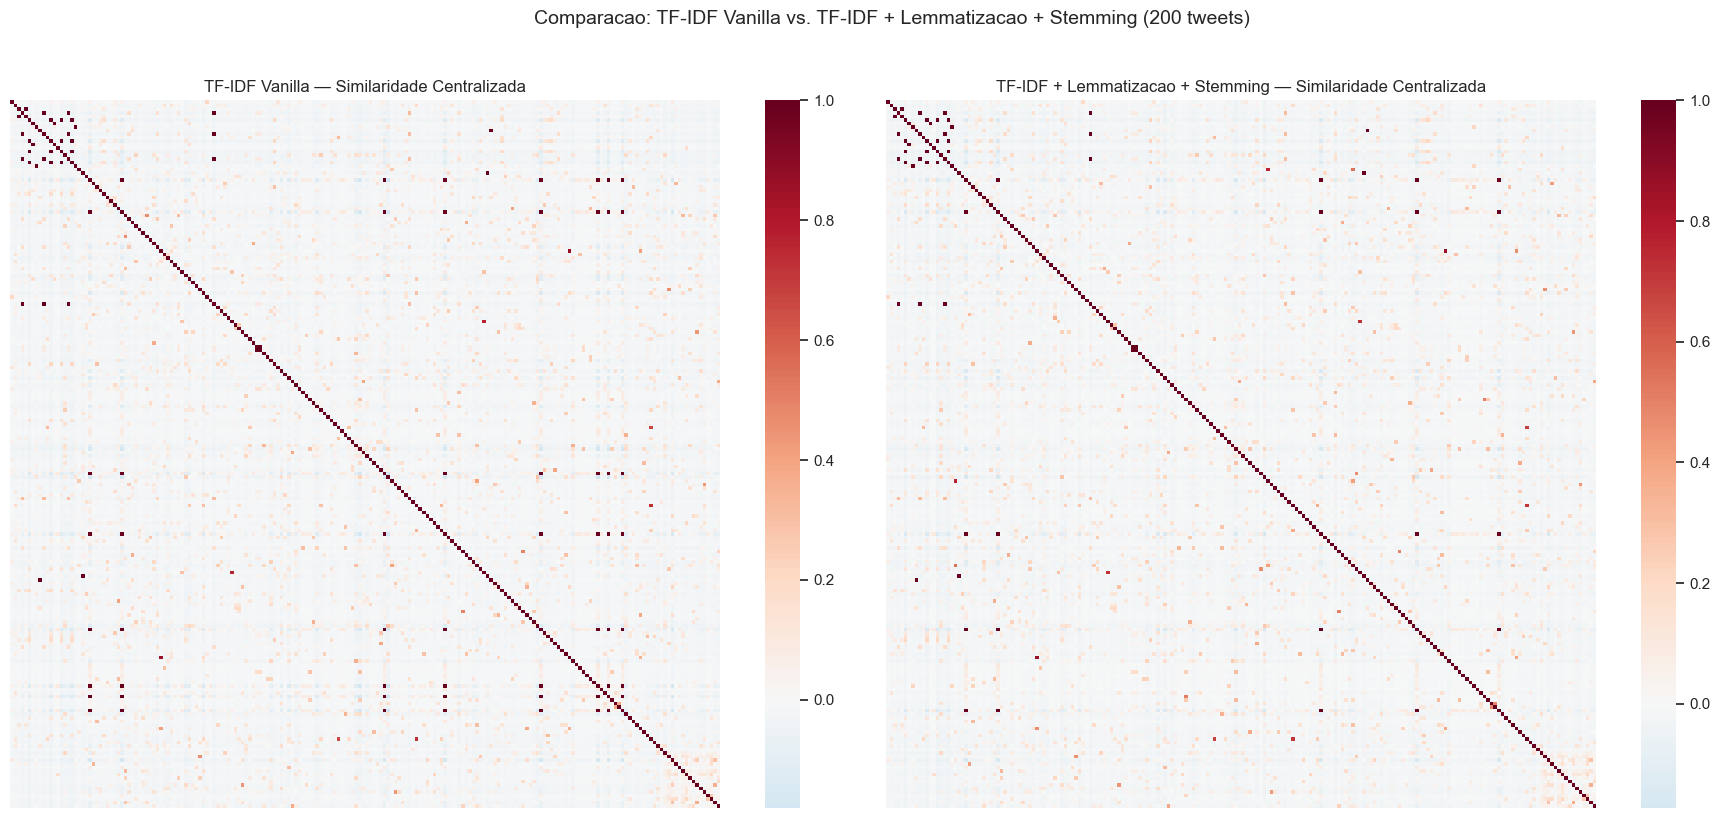

In [17]:
def parse_features_tfidf(feature_str):
    if pd.isna(feature_str):
        return {}
    try:
        return ast.literal_eval(feature_str)
    except (ValueError, SyntaxError):
        return {}

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        tfidf_config = json.load(f)
    nomes_features_vanilla = tfidf_config.get('feature_names', [])

    dicts_tfidf = df['features_tfidf_sklearn'].apply(parse_features_tfidf)
    vetores_tfidf_vanilla = np.zeros((len(df), len(nomes_features_vanilla)), dtype=np.float32)
    for i, d in enumerate(dicts_tfidf):
        for idx_f, feat_name in enumerate(nomes_features_vanilla):
            vetores_tfidf_vanilla[i, idx_f] = d.get(feat_name, 0.0)

    np.random.seed(seed)
    n_comp = min(200, len(vetores_lemmastem))
    idx_comp = np.sort(np.random.choice(len(vetores_lemmastem), size=n_comp, replace=False))

    vanilla_sample = vetores_tfidf_vanilla[idx_comp]
    lemmastem_sample = vetores_lemmastem[idx_comp]

    vanilla_sample_cent = vanilla_sample - vanilla_sample.mean(axis=0)
    lemmastem_sample_cent = lemmastem_sample - lemmastem_sample.mean(axis=0)

    sim_vanilla = cosine_similarity(vanilla_sample_cent)
    sim_lemmastem = cosine_similarity(lemmastem_sample_cent)

    vanilla_upper = sim_vanilla[np.triu_indices_from(sim_vanilla, k=1)]
    lemmastem_upper = sim_lemmastem[np.triu_indices_from(sim_lemmastem, k=1)]

    print(f'TF-IDF Vanilla (centralizado):              media={vanilla_upper.mean():.4f}, std={vanilla_upper.std():.4f}')
    print(f'TF-IDF + Lematizacao + Stemming (cent.):     media={lemmastem_upper.mean():.4f}, std={lemmastem_upper.std():.4f}')
    print(f'Correlacao entre matrizes: {np.corrcoef(sim_vanilla.flatten(), sim_lemmastem.flatten())[0,1]:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.heatmap(sim_vanilla, annot=False, cmap='RdBu_r', center=0,
                xticklabels=False, yticklabels=False, ax=axes[0])
    axes[0].set_title('TF-IDF Vanilla — Similaridade Centralizada', fontsize=12)
    sns.heatmap(sim_lemmastem, annot=False, cmap='RdBu_r', center=0,
                xticklabels=False, yticklabels=False, ax=axes[1])
    axes[1].set_title('TF-IDF + Lemmatizacao + Stemming — Similaridade Centralizada', fontsize=12)
    plt.suptitle('Comparacao: TF-IDF Vanilla vs. TF-IDF + Lemmatizacao + Stemming (200 tweets)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f'Arquivo de metadados TF-IDF nao encontrado: {json_path}')
    print('execute a entrega 2 antes para gerar os dados necessarios.')

exemplo: efeito da lematização + stemming no vocabulário

In [18]:
palavras_teste = ['correndo', 'correr', 'correu', 'corrida', 'corredor',
                  'comendo', 'comer', 'comeu', 'comida', 'comidao',
                  'magra', 'magro', 'magrinha', 'magrao', 'emagrecer']

print('efeito da lematizacao + stemming:\n')
print(f'{"Original":<20} {"Lemma (spaCy)":<20} {"Stem (NLTK)":<20}')
print('------------------------------------------------------------')
for palavra in palavras_teste:
    doc = nlp(palavra)
    lemma = doc[0].lemma_ if len(doc) > 0 else palavra
    stem = stemmer.stem(lemma.lower()) if lemma else palavra
    print(f'{palavra:<20} {lemma:<20} {stem:<20}')

Efeito da lematizacao + stemming:

Original             Lemma (spaCy)        Stem (NLTK)         
------------------------------------------------------------
correndo             correr               corr                
correr               correr               corr                
correu               correr               corr                
corrida              corrida              corr                
corredor             corredor             corredor            
comendo              comer                com                 
comer                comer                com                 
comeu                comeu                com                 
comida               comida               com                 
comidao              comidao              comida              
magra                magro                magr                
magro                magro                magr                
magrinha             magrinho             magrinh             
magrao               M

observações